"""
Spatial Gradient Analysis for Wind Speed Models (ERA5 vs DANRA)
Compares model performance across multiple offshore sites to assess spatial variability
"""



SPATIAL GRADIENT ANALYSIS - OBS vs ERA5 vs DANRA
Target height: 100.0m
Target years: 2010-2023

Found 15 OBS NetCDF files
Found 7 ERA5 CSV files
Found 3 DANRA NetCDF files
Loaded metadata for 15 stations

----------------------------------------------------------------------
PROCESSING OBSERVATIONS
----------------------------------------------------------------------

Processing OBS: fino1_20040101_20230406_INCL_STD:
  Success: 698225 hours for 2010-2023 at 101.2m

Processing OBS: fino2_20070101_20240320_INCL_STD:
  Success: 685562 hours for 2010-2023 at 102.5m

Processing OBS: fino3_200901_202406_INCL_STD:
  Success: 700465 hours for 2010-2023 at 100.6m

Processing OBS: hamburg_weathermast:
  Success: 626368 hours for 2010-2023 at 110.0m

Processing OBS: Hovsore_2004-2022:
  Success: 627292 hours for 2010-2023 at 100.0m

Processing OBS: oesterild_LMN_20190101-20240903:
  Success: 260113 hours for 2010-2023 at 106.0m

Processing OBS: oesterild_north_202112_202212:
  Skipping oesterild

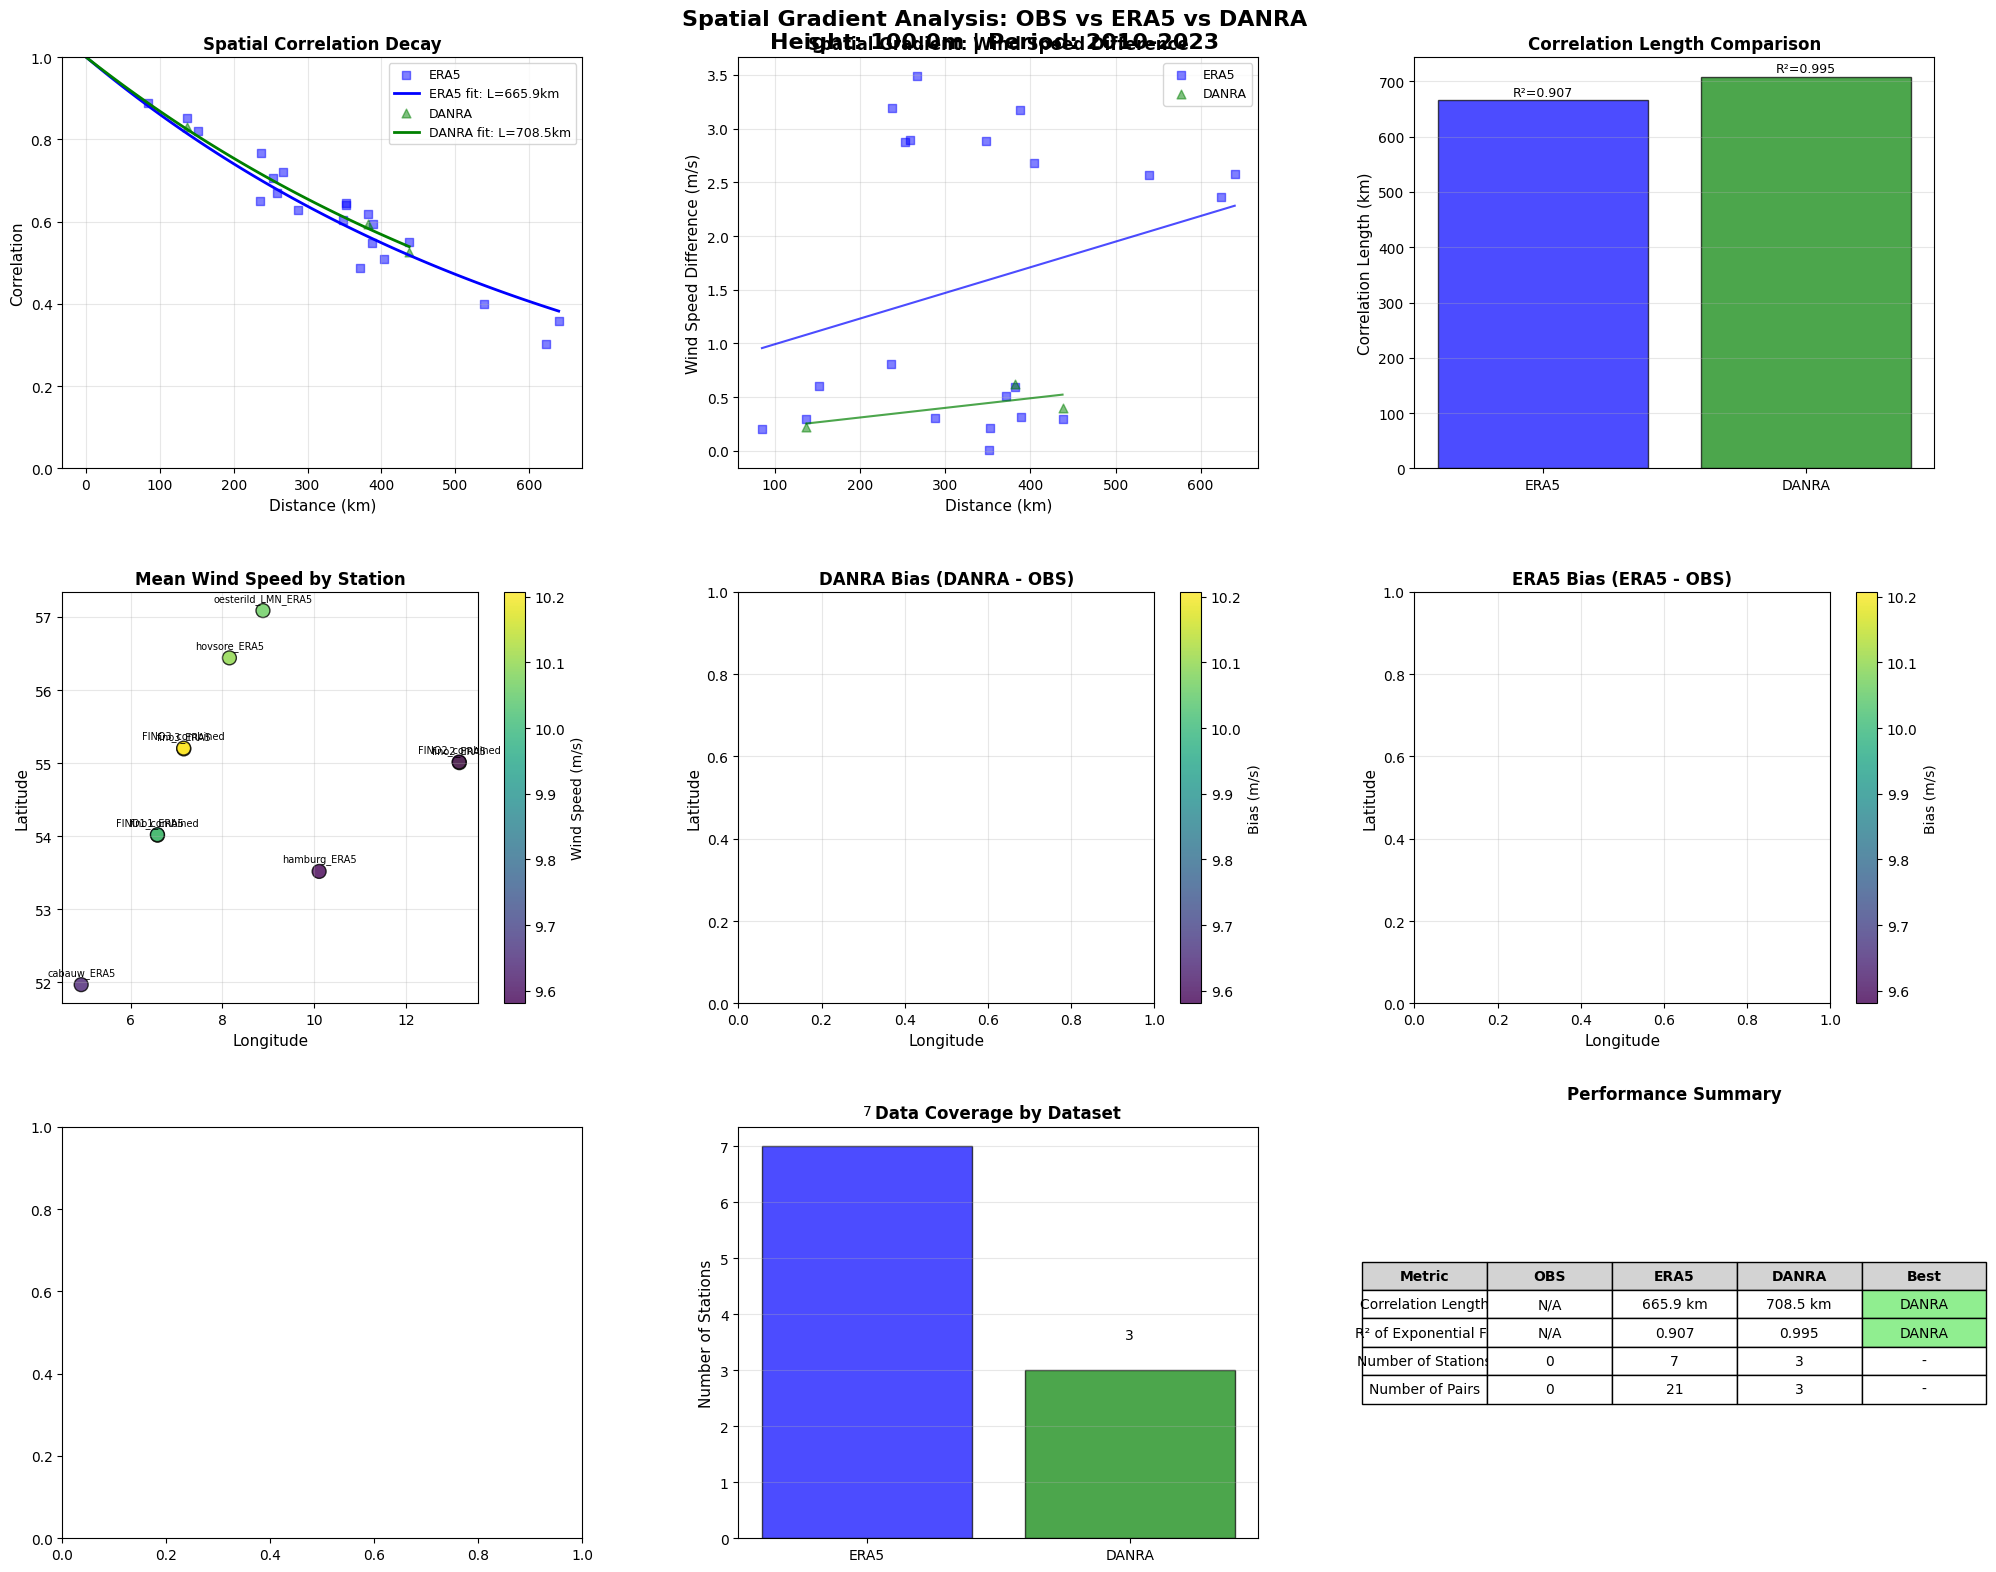

In [1]:
"""
Spatial Gradient Analysis for Wind Speed Models (OBS vs ERA5 vs DANRA)
Updated with proper colors: OBS=Orange, ERA5=Blue, DANRA=Green
"""

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, linregress
from math import radians, sin, cos, sqrt, asin
import re
import warnings
warnings.filterwarnings('ignore')

# ================================
# CONFIGURATION 
# ================================
OBS_BASE = Path("./OBS")
ERA5_BASE = Path("./ERA5")
DANRA_BASE = Path("./DANRA/new")

WIND_VARIABLE_NAMES = [
    'wind_speed', 'wind_speed_filtered', 'ws', 'wind', 'wspd',
    'wind_speed_10m', 'wind_speed_100m', 'sfc_wind', 'wind_spd',
    'WS10M', 'WS100M', 'WSPD', 'WIND_SPEED', 'wind_speed_mean',
    'wind_speed_avg', 'nl_wspd', 'F'
]

TIME_DIMENSION_NAMES = [
    'time', 'Time', 'TIME', 't', 'T', 'datetime', 'Date', 'timestamp', 'valid_time'
]

TARGET_HEIGHT = 100.0
TARGET_YEARS = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

# Correlation fit options
MIN_DISTANCE = 0.1
MAX_DISTANCE = 800.0
EXPONENTIAL_MODEL = lambda d, L: np.exp(-d / L)

# Station metadata file
STATION_METADATA_FILE = "locations.csv"

# ================================
# Helper functions
# ================================

def format_years_string(target_years):
    """Format years string for display and filenames."""
    if len(target_years) == 1:
        return str(target_years[0])
    else:
        return f"{min(target_years)}-{max(target_years)}"

def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

def find_time_dimension(ds):
    """Return name of time coordinate/dimension."""
    for coord in TIME_DIMENSION_NAMES:
        if coord in ds.coords:
            return coord
    for dim in TIME_DIMENSION_NAMES:
        if dim in ds.dims:
            return dim
    for coord in ds.coords:
        try:
            if np.issubdtype(ds[coord].dtype, np.datetime64):
                return coord
        except:
            continue
    return None

def extract_wind_speed_from_netcdf(ds, target_height, return_actual_height=False):
    """Extract wind speed series from NetCDF file."""
    wind_var = None
    for var_name in WIND_VARIABLE_NAMES:
        if var_name in ds.data_vars:
            wind_var = var_name
            break
    
    if wind_var is None:
        raise KeyError(f"No wind speed variable found. Tried: {WIND_VARIABLE_NAMES}")
    
    wind_data = ds[wind_var]
    actual_height = target_height
    
    # Handle different dimension structures
    if 'height' in wind_data.dims:
        heights = wind_data.coords['height'].values
        height_idx = np.argmin(np.abs(heights - target_height))
        actual_height = heights[height_idx]
        wind_data = wind_data.isel(height=height_idx)
    elif 'lev_wspd' in wind_data.dims:
        levels = wind_data.coords['lev_wspd'].values
        level_idx = np.argmin(np.abs(levels - target_height))
        actual_height = levels[level_idx]
        wind_data = wind_data.isel(lev_wspd=level_idx)
    elif 'altitude' in wind_data.dims:
        levels = wind_data.coords['altitude'].values
        level_idx = np.argmin(np.abs(levels - target_height))
        actual_height = levels[level_idx]
        wind_data = wind_data.isel(altitude=level_idx)
    else:
        height_like_dims = ['level', 'lev', 'z', 'altitude', 'height_above_ground']
        for dim in height_like_dims:
            if dim in wind_data.dims:
                levels = wind_data.coords[dim].values
                level_idx = np.argmin(np.abs(levels - target_height))
                actual_height = levels[level_idx]
                wind_data = wind_data.isel({dim: level_idx})
                break
    
    series = wind_data.to_series()
    
    if isinstance(series.index, pd.MultiIndex):
        time_levels = [l for l in series.index.names if l and ('time' in l.lower() or 'valid' in l.lower())]
        if time_levels:
            series = series.droplevel([l for l in series.index.names if l not in time_levels])
    
    if not isinstance(series.index, pd.DatetimeIndex):
        try:
            series.index = pd.to_datetime(series.index)
        except:
            time_dim = find_time_dimension(ds)
            if time_dim and time_dim in ds.coords:
                series.index = pd.to_datetime(ds.coords[time_dim].values)
    
    series = series.rename('wind_speed').dropna()
    
    if return_actual_height:
        return series, actual_height
    return series

def get_netcdf_coordinates(ds):
    """Extract coordinates from NetCDF file."""
    lat, lon = None, None
    
    for name in ['latitude', 'lat', 'actual_latitude']:
        if name in ds.coords:
            lat = float(ds.coords[name].values)
            break
    for name in ['longitude', 'lon', 'actual_longitude']:
        if name in ds.coords:
            lon = float(ds.coords[name].values)
            break
    
    if lat is None and 'latitude' in ds.attrs:
        lat = float(ds.attrs['latitude'])
    if lon is None and 'longitude' in ds.attrs:
        lon = float(ds.attrs['longitude'])
    
    if lat is None and 'latitude' in ds.data_vars:
        lat = float(ds['latitude'].values)
    if lon is None and 'longitude' in ds.data_vars:
        lon = float(ds['longitude'].values)
    
    if lat is None or lon is None:
        raise KeyError(f"Could not find coordinates. Available coords: {list(ds.coords.keys())}")
    
    return lat, lon

def load_station_metadata(metadata_file):
    """Load station metadata from CSV file."""
    if not Path(metadata_file).exists():
        print(f"Warning: Station metadata file {metadata_file} not found")
        return {}
    
    df_meta = pd.read_csv(metadata_file)
    station_info = {}
    
    for _, row in df_meta.iterrows():
        station_name = row['station'].strip()
        
        lev_wspd = []
        if pd.notna(row.get('lev_wspd', '')) and str(row['lev_wspd']).strip():
            wspd_str = str(row['lev_wspd']).strip()
            if ',' in wspd_str:
                lev_wspd = [float(h.strip()) for h in wspd_str.split(',') if h.strip()]
            else:
                lev_wspd = [float(h) for h in wspd_str.split() if h.strip()]
        
        station_info[station_name] = {
            'lat': float(row['lat']),
            'lon': float(row['lon']),
            'lev_wspd': lev_wspd,
        }
    
    print(f"Loaded metadata for {len(station_info)} stations")
    return station_info

def get_csv_coordinates(filename, df=None, station_metadata=None):
    """Extract coordinates from CSV filename or metadata."""
    stem = Path(filename).stem
    
    station_name = stem
    for suffix in ['_ERA5', '_ERA5_CSV', '_obs', '_station', '_met', '_combined']:
        if station_name.endswith(suffix):
            station_name = station_name[:-len(suffix)]
            break
    
    if station_metadata and station_name in station_metadata:
        info = station_metadata[station_name]
        return info['lat'], info['lon']
    
    if station_metadata:
        for meta_station in station_metadata.keys():
            if meta_station.lower() in stem.lower() or stem.lower() in meta_station.lower():
                info = station_metadata[meta_station]
                return info['lat'], info['lon']
    
    pattern = r'([-+]?\d*\.?\d+)[_-]([-+]?\d*\.?\d+)$'
    match = re.search(pattern, stem)
    if match:
        lat = float(match.group(1))
        lon = float(match.group(2))
        return lat, lon
    
    if df is not None:
        if 'latitude' in df.columns and 'longitude' in df.columns:
            return float(df['latitude'].iloc[0]), float(df['longitude'].iloc[0])
        if 'lat' in df.columns and 'lon' in df.columns:
            return float(df['lat'].iloc[0]), float(df['lon'].iloc[0])
    
    return None, None

def extract_wind_speed_from_csv(df, target_height, station_name=None, station_metadata=None, return_actual_height=False):
    """Extract wind speed series from ERA5 CSV DataFrame."""
    available_heights = []
    
    if station_name and station_metadata and station_name in station_metadata:
        available_heights = station_metadata[station_name]['lev_wspd']
    
    if not available_heights:
        for col in df.columns:
            if col.startswith('U') and col[1:].isdigit():
                available_heights.append(int(col[1:]))
        available_heights.sort()
    
    if not available_heights:
        raise ValueError(f"No wind speed columns found. Available: {df.columns.tolist()}")
    
    closest_height = min(available_heights, key=lambda h: abs(h - target_height))
    wind_column = f'U{closest_height}'
    
    if wind_column not in df.columns:
        alt_columns = [f'ws_{closest_height}', f'wind_speed_{closest_height}', f'wspd_{closest_height}']
        for alt in alt_columns:
            if alt in df.columns:
                wind_column = alt
                break
        else:
            raise ValueError(f"Could not find wind speed column for height {closest_height}m")
    
    series = df[wind_column].copy().rename('wind_speed').dropna()
    
    if return_actual_height:
        return series, closest_height
    return series

# ================================
# MULTI-YEAR DATA PROCESSING FUNCTIONS
# ================================

def process_observations_multi_year(nc_files, target_height, target_years):
    """Process OBS NetCDF files for multiple years."""
    stations = {}
    
    for f in nc_files:
        try:
            ds = xr.open_dataset(f, decode_times=True)
            print(f"\nProcessing OBS: {f.stem}:")
            
            series, actual_h = extract_wind_speed_from_netcdf(ds, target_height, return_actual_height=True)
            lat, lon = get_netcdf_coordinates(ds)
            
            # Filter by multiple years
            series = series[series.index.year.isin(target_years)]
            
            if len(series) > 0:
                stations[f.stem] = {
                    'series': series,
                    'lat': lat,
                    'lon': lon,
                    'actual_height': actual_h
                }
                years_str = format_years_string(target_years)
                print(f"  Success: {len(series)} hours for {years_str} at {actual_h:.1f}m")
            else:
                print(f"  No data for selected years")
            
            ds.close()
            
        except Exception as e:
            print(f"  Skipping {f.name}: {e}")
    
    return stations

def process_era5_multi_year(csv_files, target_height, target_years, station_metadata):
    """Process ERA5 CSV files for multiple years."""
    stations = {}
    
    for f in csv_files:
        try:
            print(f"\nProcessing ERA5: {f.stem}:")
            
            df = pd.read_csv(f, parse_dates=['time'])
            df.set_index('time', inplace=True)
            
            station_name = f.stem
            series, actual_h = extract_wind_speed_from_csv(df, target_height, station_name, station_metadata, return_actual_height=True)
            lat, lon = get_csv_coordinates(f, df, station_metadata)
            
            if lat is None or lon is None:
                print(f"  Skipping: Could not determine coordinates")
                continue
            
            # Filter by multiple years
            series = series[series.index.year.isin(target_years)]
            
            if len(series) > 0:
                stations[station_name] = {
                    'series': series,
                    'lat': lat,
                    'lon': lon,
                    'actual_height': actual_h
                }
                years_str = format_years_string(target_years)
                print(f"  Success: {len(series)} hours for {years_str} at {actual_h:.1f}m")
            else:
                print(f"  No data for selected years")
            
        except Exception as e:
            print(f"  Skipping {f.name}: {e}")
    
    return stations

def process_danra_multi_year(nc_files, target_height, target_years):
    """Process DANRA NetCDF files with proper time decoding using 'hours since 1990-09-01'."""
    stations = {}
    
    for f in nc_files:
        try:
            print(f"\nProcessing DANRA: {f.stem}:")
            
            # Open without automatic time decoding
            ds = xr.open_dataset(f, decode_times=False)
            
            # Decode analysis_time using the units attribute
            if 'analysis_time' in ds.variables:
                # Get the units attribute
                units_attr = ds.analysis_time.attrs.get('units', '')
                print(f"    Time units: {units_attr}")
                
                # Parse the reference date from units string
                import re
                match = re.search(r'hours since (.+)', units_attr)
                if match:
                    ref_date_str = match.group(1).split('+')[0].split('-00:00')[0]
                    ref_date = pd.to_datetime(ref_date_str)
                    print(f"    Reference date: {ref_date}")
                else:
                    # Default fallback
                    ref_date = pd.to_datetime('1990-09-01')
                    print(f"    Using default reference date: {ref_date}")
                
                # Convert analysis_time from hours since reference date to datetime
                analysis_time_hours = ds.analysis_time.values
                analysis_time = ref_date + pd.to_timedelta(analysis_time_hours, unit='h')
                
                # Handle forecast_duration (should be in hours)
                if 'forecast_duration' in ds.variables:
                    forecast_hours = ds.forecast_duration.values
                    if hasattr(ds.forecast_duration, 'attrs'):
                        forecast_units = ds.forecast_duration.attrs.get('units', 'hours')
                    else:
                        forecast_units = 'hours'
                    
                    if 'hour' in forecast_units.lower():
                        forecast_timedelta = pd.to_timedelta(forecast_hours, unit='h')
                    else:
                        forecast_timedelta = pd.to_timedelta(forecast_hours)
                    
                    valid_time = analysis_time + forecast_timedelta
                else:
                    valid_time = analysis_time
                
                ds = ds.assign_coords(valid_time=('valid_time', valid_time))
                print(f"    Time range: {valid_time.min()} to {valid_time.max()}")
                print(f"    Years in data: {sorted(set(valid_time.year))}")
            else:
                print(f"  Missing analysis_time variable")
                ds.close()
                continue
            
            # Calculate wind speed from u and v components
            if 'u' in ds.variables and 'v' in ds.variables:
                ds['wind_speed'] = np.sqrt(ds['u']**2 + ds['v']**2)
                ds['wind_speed'].attrs['units'] = 'm/s'
                print(f"    Calculated wind speed from u/v components")
            else:
                print(f"  No u/v components found")
                ds.close()
                continue
            
            # Get coordinates
            lat = float(ds.lat.values) if 'lat' in ds.coords else None
            lon = float(ds.lon.values) if 'lon' in ds.coords else None
            
            if lat is None or lon is None:
                lat = ds.attrs.get('lat', ds.attrs.get('latitude', None))
                lon = ds.attrs.get('lon', ds.attrs.get('longitude', None))
            
            if lat is None or lon is None:
                print(f"  Cannot find coordinates")
                ds.close()
                continue
            
            print(f"    Coordinates: lat={lat:.4f}, lon={lon:.4f}")
            
            # Get altitudes
            if 'altitude' in ds.coords:
                altitudes = ds.altitude.values
                print(f"    Available altitudes: {altitudes}")
                
                altitude_idx = np.argmin(np.abs(altitudes - target_height))
                actual_altitude = altitudes[altitude_idx]
                print(f"    Using altitude {actual_altitude:.1f}m (closest to {target_height}m)")
            else:
                print(f"  No altitude coordinate")
                ds.close()
                continue
            
            # Extract wind speed at chosen altitude
            wind_speed = ds['wind_speed'].isel(altitude=altitude_idx)
            
            # Create pandas Series with proper time index
            if 'valid_time' in wind_speed.coords:
                time_index = pd.DatetimeIndex(wind_speed.valid_time.values)
            elif 'time' in wind_speed.coords:
                time_index = pd.DatetimeIndex(wind_speed.time.values)
            else:
                print(f"  No time coordinate found")
                ds.close()
                continue
            
            series = pd.Series(wind_speed.values, index=time_index)
            series = series.dropna()
            series = series[series.index.year.isin(target_years)]
            
            if len(series) > 0:
                station_name = f.stem
                stations[station_name] = {
                    'series': series, 
                    'lat': float(lat), 
                    'lon': float(lon),
                    'altitude': actual_altitude
                }
                years_str = format_years_string(target_years)
                print(f"  Success: {len(series)} hours for {years_str} at {actual_altitude:.1f}m")
                print(f"    Time range: {series.index.min()} to {series.index.max()}")
            else:
                print(f"  No data for selected years {target_years}")
                all_series = pd.Series(wind_speed.values, index=time_index)
                all_series = all_series.dropna()
                if len(all_series) > 0:
                    available_years = sorted(set(all_series.index.year))
                    print(f"    Available years in file: {available_years}")
                    
                    present_years = [y for y in target_years if y in available_years]
                    if present_years:
                        print(f"    Years from target that ARE available: {present_years}")
                    else:
                        print(f"    None of the target years {target_years} are in this file")
                else:
                    print(f"    No valid time series extracted")
            
            ds.close()
            
        except Exception as e:
            print(f"  Skipping {f.name}: {e}")
            import traceback
            traceback.print_exc()
    
    return stations

# ================================
# SPATIAL GRADIENT ANALYSIS FUNCTIONS
# ================================

def compute_spatial_metrics(stations, dataset_name, target_years):
    """Compute comprehensive spatial metrics for a dataset."""
    if len(stations) < 2:
        print(f"  {dataset_name}: Need at least 2 stations, got {len(stations)}")
        return None
    
    years_str = format_years_string(target_years)
    
    # Align time series
    common_index = None
    for name, info in stations.items():
        idx = info['series'].index
        if common_index is None:
            common_index = idx
        else:
            common_index = common_index.intersection(idx)
    
    if len(common_index) < 100:
        print(f"  {dataset_name}: Warning - only {len(common_index)} common timesteps for {years_str}")
    
    # Build DataFrame
    df_aligned = pd.DataFrame()
    for name, info in stations.items():
        df_aligned[name] = info['series'].reindex(common_index)
    
    df_aligned = df_aligned.dropna(axis=1, how='all')
    station_names = list(df_aligned.columns)
    n = len(station_names)
    
    if n < 2:
        return None
    
    # Get coordinates
    coords = []
    valid_stations = []
    for name in station_names:
        if name in stations:
            coords.append((stations[name]['lat'], stations[name]['lon']))
            valid_stations.append(name)
    
    # Calculate mean wind speeds
    mean_winds = df_aligned.mean()
    
    # Calculate pairwise metrics
    distances = []
    correlations = []
    wind_diffs = []
    pair_names = []
    
    for i in range(n):
        for j in range(i+1, n):
            dist = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            
            if MIN_DISTANCE <= dist <= MAX_DISTANCE:
                corr = df_aligned[valid_stations[i]].corr(df_aligned[valid_stations[j]])
                wind_diff = abs(mean_winds[valid_stations[i]] - mean_winds[valid_stations[j]])
                
                if not np.isnan(corr):
                    distances.append(dist)
                    correlations.append(corr)
                    wind_diffs.append(wind_diff)
                    pair_names.append(f"{valid_stations[i]}-{valid_stations[j]}")
    
    print(f"  {dataset_name}: {len(distances)} valid pairs for {years_str}")
    
    # Fit exponential model to correlations
    correlation_length = None
    r_squared = None
    
    if len(distances) >= 3:
        try:
            distances_arr = np.array(distances)
            correlations_arr = np.array(correlations)
            valid_mask = ~(np.isnan(distances_arr) | np.isnan(correlations_arr))
            distances_clean = distances_arr[valid_mask]
            correlations_clean = correlations_arr[valid_mask]
            
            if len(distances_clean) >= 3:
                popt, _ = curve_fit(EXPONENTIAL_MODEL, distances_clean, correlations_clean, 
                                   p0=50.0, bounds=(0, np.inf))
                correlation_length = popt[0]
                
                predicted = EXPONENTIAL_MODEL(distances_clean, correlation_length)
                ss_res = np.sum((correlations_clean - predicted) ** 2)
                ss_tot = np.sum((correlations_clean - np.mean(correlations_clean)) ** 2)
                r_squared = 1 - (ss_res / ss_tot)
        except Exception as e:
            print(f"  Fit failed: {e}")
    
    return {
        'distances': distances,
        'correlations': correlations,
        'wind_diffs': wind_diffs,
        'pair_names': pair_names,
        'correlation_length': correlation_length,
        'r_squared': r_squared,
        'mean_winds': mean_winds,
        'coords': coords,
        'station_names': valid_stations,
        'n_pairs': len(distances)
    }

def create_spatial_gradient_plots(obs_metrics, era5_metrics, danra_metrics, target_height, target_years):
    """Create comprehensive spatial gradient visualizations."""
    
    years_str = format_years_string(target_years)
    fig = plt.figure(figsize=(20, 16))
    
    # Colors: OBS=Orange, ERA5=Blue, DANRA=Green
    colors = {
        'OBS': 'orange',
        'ERA5': 'blue',
        'DANRA': 'green'
    }
    markers = {
        'OBS': 'o',
        'ERA5': 's',
        'DANRA': '^'
    }
    
    # 1. Correlation vs Distance (with exponential fits)
    ax1 = plt.subplot(3, 3, 1)
    
    datasets = [('OBS', obs_metrics), ('ERA5', era5_metrics), ('DANRA', danra_metrics)]
    
    for name, metrics in datasets:
        if metrics and metrics['distances']:
            ax1.scatter(metrics['distances'], metrics['correlations'], 
                       alpha=0.5, s=40, color=colors[name], marker=markers[name], label=f'{name}')
            
            if metrics['correlation_length']:
                d_fit = np.linspace(0, max(metrics['distances']), 100)
                ax1.plot(d_fit, EXPONENTIAL_MODEL(d_fit, metrics['correlation_length']), 
                        '-', color=colors[name], linewidth=2,
                        label=f'{name} fit: L={metrics["correlation_length"]:.1f}km')
    
    ax1.set_xlabel('Distance (km)', fontsize=11)
    ax1.set_ylabel('Correlation', fontsize=11)
    ax1.set_title('Spatial Correlation Decay', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # 2. Wind Speed Difference vs Distance
    ax2 = plt.subplot(3, 3, 2)
    
    for name, metrics in datasets:
        if metrics and metrics['wind_diffs']:
            ax2.scatter(metrics['distances'], metrics['wind_diffs'], 
                       alpha=0.5, s=40, color=colors[name], marker=markers[name], label=f'{name}')
            
            # Add trend line
            if len(metrics['distances']) > 1:
                z = np.polyfit(metrics['distances'], metrics['wind_diffs'], 1)
                p = np.poly1d(z)
                ax2.plot(np.sort(metrics['distances']), p(np.sort(metrics['distances'])), 
                        '-', color=colors[name], linewidth=1.5, alpha=0.7)
    
    ax2.set_xlabel('Distance (km)', fontsize=11)
    ax2.set_ylabel('Wind Speed Difference (m/s)', fontsize=11)
    ax2.set_title('Spatial Gradient: Wind Speed Difference', fontsize=12, fontweight='bold')
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Correlation Length Comparison (Bar Chart)
    ax3 = plt.subplot(3, 3, 3)
    
    names = []
    lengths = []
    r2_values = []
    bar_colors = []
    
    for name, metrics in [('OBS', obs_metrics), ('ERA5', era5_metrics), ('DANRA', danra_metrics)]:
        if metrics and metrics['correlation_length']:
            names.append(name)
            lengths.append(metrics['correlation_length'])
            r2_values.append(metrics['r_squared'])
            bar_colors.append(colors[name])
    
    if names:
        bars = ax3.bar(names, lengths, color=bar_colors, alpha=0.7, edgecolor='black')
        ax3.set_ylabel('Correlation Length (km)', fontsize=11)
        ax3.set_title('Correlation Length Comparison', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
        
        # Add R² values as text
        for i, (bar, r2) in enumerate(zip(bars, r2_values)):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                    f'R²={r2:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 4. Mean Wind Speed Map
    ax4 = plt.subplot(3, 3, 4)
    
    for name, metrics in datasets:
        if metrics and metrics['coords']:
            lats = [c[0] for c in metrics['coords']]
            lons = [c[1] for c in metrics['coords']]
            means = metrics['mean_winds'].values
            
            scatter = ax4.scatter(lons, lats, c=means, cmap='viridis', 
                                 s=100, edgecolor='black', linewidth=1, alpha=0.8)
            
            for i, station in enumerate(metrics['station_names']):
                ax4.annotate(station, (lons[i], lats[i]), 
                           fontsize=7, ha='center', va='bottom', xytext=(0, 5),
                           textcoords='offset points')
    
    ax4.set_xlabel('Longitude', fontsize=11)
    ax4.set_ylabel('Latitude', fontsize=11)
    ax4.set_title('Mean Wind Speed by Station', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax4, label='Wind Speed (m/s)')
    ax4.grid(True, alpha=0.3)
    
    # 5. DANRA Bias Map (DANRA - OBS)
    ax5 = plt.subplot(3, 3, 5)
    
    if obs_metrics and danra_metrics:
        obs_stations = set(obs_metrics['station_names'])
        danra_stations = set(danra_metrics['station_names'])
        common = obs_stations.intersection(danra_stations)
        
        if common:
            biases = []
            lats = []
            lons = []
            station_names = []
            
            for station in common:
                obs_mean = obs_metrics['mean_winds'][station]
                danra_mean = danra_metrics['mean_winds'][station]
                bias = danra_mean - obs_mean
                
                idx = obs_metrics['station_names'].index(station)
                lats.append(obs_metrics['coords'][idx][0])
                lons.append(obs_metrics['coords'][idx][1])
                biases.append(bias)
                station_names.append(station)
            
            scatter = ax5.scatter(lons, lats, c=biases, cmap='RdBu_r', 
                                 s=150, edgecolor='black', linewidth=1.5, vmin=-0.5, vmax=0.5)
            
            for i, station in enumerate(station_names):
                ax5.annotate(f'{station}\n({biases[i]:+.2f})', (lons[i], lats[i]), 
                           fontsize=7, ha='center', va='bottom')
    
    ax5.set_xlabel('Longitude', fontsize=11)
    ax5.set_ylabel('Latitude', fontsize=11)
    ax5.set_title('DANRA Bias (DANRA - OBS)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax5, label='Bias (m/s)')
    ax5.grid(True, alpha=0.3)
    
    # 6. ERA5 Bias Map (ERA5 - OBS)
    ax6 = plt.subplot(3, 3, 6)
    
    if obs_metrics and era5_metrics:
        obs_stations = set(obs_metrics['station_names'])
        era5_stations = set(era5_metrics['station_names'])
        common = obs_stations.intersection(era5_stations)
        
        if common:
            biases = []
            lats = []
            lons = []
            station_names = []
            
            for station in common:
                obs_mean = obs_metrics['mean_winds'][station]
                era5_mean = era5_metrics['mean_winds'][station]
                bias = era5_mean - obs_mean
                
                idx = obs_metrics['station_names'].index(station)
                lats.append(obs_metrics['coords'][idx][0])
                lons.append(obs_metrics['coords'][idx][1])
                biases.append(bias)
                station_names.append(station)
            
            scatter = ax6.scatter(lons, lats, c=biases, cmap='RdBu_r', 
                                 s=150, edgecolor='black', linewidth=1.5, vmin=-0.5, vmax=0.5)
            
            for i, station in enumerate(station_names):
                ax6.annotate(f'{station}\n({biases[i]:+.2f})', (lons[i], lats[i]), 
                           fontsize=7, ha='center', va='bottom')
    
    ax6.set_xlabel('Longitude', fontsize=11)
    ax6.set_ylabel('Latitude', fontsize=11)
    ax6.set_title('ERA5 Bias (ERA5 - OBS)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax6, label='Bias (m/s)')
    ax6.grid(True, alpha=0.3)
    
    # 7. Cross-Correlation Matrix (OBS)
    ax7 = plt.subplot(3, 3, 7)
    
    if obs_metrics and len(obs_metrics['station_names']) > 1:
        n = len(obs_metrics['station_names'])
        corr_matrix = np.ones((n, n))
        
        for i in range(n):
            for j in range(i+1, n):
                for k, pair in enumerate(obs_metrics['pair_names']):
                    stations = pair.split('-')
                    if (stations[0] == obs_metrics['station_names'][i] and stations[1] == obs_metrics['station_names'][j]) or \
                       (stations[0] == obs_metrics['station_names'][j] and stations[1] == obs_metrics['station_names'][i]):
                        corr_matrix[i, j] = obs_metrics['correlations'][k]
                        corr_matrix[j, i] = obs_metrics['correlations'][k]
                        break
        
        im = ax7.imshow(corr_matrix, cmap='RdBu_r', vmin=0.5, vmax=1.0)
        ax7.set_xticks(range(n))
        ax7.set_xticklabels(obs_metrics['station_names'], rotation=45, ha='right', fontsize=8)
        ax7.set_yticks(range(n))
        ax7.set_yticklabels(obs_metrics['station_names'], fontsize=8)
        ax7.set_title('OBS Cross-Correlation Matrix', fontsize=12, fontweight='bold')
        plt.colorbar(im, ax=ax7, label='Correlation')
    
    # 8. Model Comparison: Number of Stations
    ax8 = plt.subplot(3, 3, 8)
    
    n_stations = []
    model_names = []
    model_colors = []
    
    for name, metrics in [('OBS', obs_metrics), ('ERA5', era5_metrics), ('DANRA', danra_metrics)]:
        if metrics:
            n_stations.append(len(metrics['station_names']))
            model_names.append(name)
            model_colors.append(colors[name])
    
    if n_stations:
        bars = ax8.bar(model_names, n_stations, color=model_colors, alpha=0.7, edgecolor='black')
        ax8.set_ylabel('Number of Stations', fontsize=11)
        ax8.set_title('Data Coverage by Dataset', fontsize=12, fontweight='bold')
        ax8.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, n in zip(bars, n_stations):
            ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(n), ha='center', va='bottom', fontsize=10)
    
    # 9. Performance Summary Table
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('tight')
    ax9.axis('off')
    
    table_data = [['Metric', 'OBS', 'ERA5', 'DANRA', 'Best']]
    
    # Correlation Length
    obs_L = f"{obs_metrics['correlation_length']:.1f} km" if obs_metrics and obs_metrics['correlation_length'] else 'N/A'
    era5_L = f"{era5_metrics['correlation_length']:.1f} km" if era5_metrics and era5_metrics['correlation_length'] else 'N/A'
    danra_L = f"{danra_metrics['correlation_length']:.1f} km" if danra_metrics and danra_metrics['correlation_length'] else 'N/A'
    
    best_L = 'DANRA' if danra_metrics and danra_metrics['correlation_length'] and \
                      era5_metrics and era5_metrics['correlation_length'] and \
                      danra_metrics['correlation_length'] > era5_metrics['correlation_length'] else 'ERA5'
    
    table_data.append(['Correlation Length', obs_L, era5_L, danra_L, best_L])
    
    # R² of fit
    obs_R2 = f"{obs_metrics['r_squared']:.3f}" if obs_metrics and obs_metrics['r_squared'] else 'N/A'
    era5_R2 = f"{era5_metrics['r_squared']:.3f}" if era5_metrics and era5_metrics['r_squared'] else 'N/A'
    danra_R2 = f"{danra_metrics['r_squared']:.3f}" if danra_metrics and danra_metrics['r_squared'] else 'N/A'
    
    best_R2 = 'DANRA' if danra_metrics and danra_metrics['r_squared'] and \
                       era5_metrics and era5_metrics['r_squared'] and \
                       danra_metrics['r_squared'] > era5_metrics['r_squared'] else 'ERA5'
    
    table_data.append(['R² of Exponential Fit', obs_R2, era5_R2, danra_R2, best_R2])
    
    # Number of stations
    n_obs = len(obs_metrics['station_names']) if obs_metrics else 0
    n_era5 = len(era5_metrics['station_names']) if era5_metrics else 0
    n_danra = len(danra_metrics['station_names']) if danra_metrics else 0
    
    table_data.append(['Number of Stations', f'{n_obs}', f'{n_era5}', f'{n_danra}', '-'])
    
    # Number of pairs
    n_pairs_obs = obs_metrics['n_pairs'] if obs_metrics else 0
    n_pairs_era5 = era5_metrics['n_pairs'] if era5_metrics else 0
    n_pairs_danra = danra_metrics['n_pairs'] if danra_metrics else 0
    
    table_data.append(['Number of Pairs', f'{n_pairs_obs}', f'{n_pairs_era5}', f'{n_pairs_danra}', '-'])
    
    table = ax9.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Color code the 'Best' column
    for i in range(1, len(table_data)):
        if 'DANRA' in table_data[i][4]:
            table[(i, 4)].set_facecolor('#90EE90')
        elif 'ERA5' in table_data[i][4]:
            table[(i, 4)].set_facecolor('#87CEEB')
    
    # Highlight header
    for j in range(5):
        table[(0, j)].set_facecolor('#D3D3D3')
        table[(0, j)].set_text_props(weight='bold')
    
    ax9.set_title('Performance Summary', fontsize=12, fontweight='bold', pad=20)
    
    # Overall title
    plt.suptitle(f'Spatial Gradient Analysis: OBS vs ERA5 vs DANRA\n'
                f'Height: {target_height}m | Period: {years_str}',
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.3, wspace=0.3)
    
    # Save figure
    output_filename = f'spatial_gradient_analysis_{target_height}m_{years_str}.png'
    plt.savefig(output_filename, dpi=150, bbox_inches='tight')
    print(f"\nSpatial gradient plot saved as '{output_filename}'")
    plt.show()
    
    return fig

# ================================
# MAIN SCRIPT
# ================================

def main():
    years_str = format_years_string(TARGET_YEARS)
    
    print("=" * 70)
    print("SPATIAL GRADIENT ANALYSIS - OBS vs ERA5 vs DANRA")
    print(f"Target height: {TARGET_HEIGHT}m")
    print(f"Target years: {years_str}")
    print("=" * 70)
    
    # Find files
    obs_files = sorted(OBS_BASE.glob("*.nc"))
    era5_files = sorted(ERA5_BASE.glob("*.csv"))
    danra_files = sorted(DANRA_BASE.glob("*.nc"))
    
    print(f"\nFound {len(obs_files)} OBS NetCDF files")
    print(f"Found {len(era5_files)} ERA5 CSV files")
    print(f"Found {len(danra_files)} DANRA NetCDF files")
    
    # Load station metadata
    station_metadata = load_station_metadata(STATION_METADATA_FILE)
    
    # Process OBS data
    print("\n" + "-" * 70)
    print("PROCESSING OBSERVATIONS")
    print("-" * 70)
    obs_stations = process_observations_multi_year(obs_files, TARGET_HEIGHT, TARGET_YEARS)
    
    # Process ERA5 data
    print("\n" + "-" * 70)
    print("PROCESSING ERA5")
    print("-" * 70)
    era5_stations = process_era5_multi_year(era5_files, TARGET_HEIGHT, TARGET_YEARS, station_metadata)
    
    # Process DANRA data
    print("\n" + "-" * 70)
    print("PROCESSING DANRA")
    print("-" * 70)
    danra_stations = process_danra_multi_year(danra_files, TARGET_HEIGHT, TARGET_YEARS)
    
    # Compute spatial metrics
    print("\n" + "-" * 70)
    print("COMPUTING SPATIAL METRICS")
    print("-" * 70)
    
    obs_metrics = compute_spatial_metrics(obs_stations, "OBS", TARGET_YEARS)
    era5_metrics = compute_spatial_metrics(era5_stations, "ERA5", TARGET_YEARS)
    danra_metrics = compute_spatial_metrics(danra_stations, "DANRA", TARGET_YEARS)
    
    # Print summary
    print("\n" + "=" * 70)
    print("SPATIAL METRICS SUMMARY")
    print("=" * 70)
    
    for name, metrics in [('OBS', obs_metrics), ('ERA5', era5_metrics), ('DANRA', danra_metrics)]:
        if metrics:
            print(f"\n{name}:")
            print(f"  Stations: {len(metrics['station_names'])}")
            print(f"  Pairs: {metrics['n_pairs']}")
            if metrics['correlation_length']:
                print(f"  Correlation Length: {metrics['correlation_length']:.2f} km (R²={metrics['r_squared']:.3f})")
            else:
                print(f"  Correlation Length: Fit failed")
    
    # Create visualizations
    print("\n" + "-" * 70)
    print("GENERATING SPATIAL GRADIENT PLOTS")
    print("-" * 70)
    
    create_spatial_gradient_plots(obs_metrics, era5_metrics, danra_metrics, TARGET_HEIGHT, TARGET_YEARS)
    
    # Return results for further analysis
    return {
        'obs': obs_metrics,
        'era5': era5_metrics,
        'danra': danra_metrics,
        'obs_stations': obs_stations,
        'era5_stations': era5_stations,
        'danra_stations': danra_stations
    }

if __name__ == "__main__":
    results = main()